# Mean-state nudge experiment — comprehensive analysis

Three no-aerosol zero-wind runs:

| Label | Experiment | RT |
|-------|-----------|-----|
| **1D free** | `no_aerosols_zero_wind` | 2stream |
| **3D free** | `no_aerosols_zero_wind` | raytracer |
| **3D nudged** | `mean_state_nudge/nudge_3600s` | raytracer (τ = 3600 s) |

**Key finding**: nudge LWP integral (+88 g m⁻² h) is 3.5× larger than the free 3D−1D gap (+25 g m⁻² h).  
Mechanism is an open question.

**Sections**
1. LWP overview
2. Thermodynamic structure (time-height, subcloud q_t)
3. Surface energy balance (components, residual, EF, cloud-conditioned)
4. Entrainment (base 1D / base 3D / nudge 3D)
5. Cloud-root turbulent structure (vertical flux profiles)

In [1]:
import os, sys, pickle, warnings
import numpy as np
import netCDF4 as nc
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))                      # analysis/
sys.path.insert(0, str(Path.cwd().parent / "cloud_roots"))      # analysis/cloud_roots/

from cass_analysis import (
    load_stats,
    load_stats_ensemble,
    load_3d_nc,
    load_xy_files,
    compute_normalized_cloud_root_profiles,
    conditioned_means_ensemble,
    lwp_integral,
    lwp_normalized_diff,
    seb_residual,
    evaporative_fraction,
    plot_flux_conditioned,
    RunSet,
    _to_plottime,
    rho, cp, Lv,
)
from catalog import make_runset

In [2]:
SCRATCH        = Path('/pscratch/sd/m/mpowell/CASS_LES')
COMPOSITE_ROOT = SCRATCH / 'analysis/cloud_root_composite'
N_REPS  = 4
LST_OFF = 5.5   # t=0 corresponds to 05:30 LST

KEY_CTRL  = "no_aerosols_zero_wind"
KEY_NUDGE = "mean_state_nudge_3600s"

STYLE = {
    "1D free":   dict(color="C0", ls="-",  lw=1.5),
    "3D free":   dict(color="C1", ls="--", lw=1.5),
    "3D nudged": dict(color="C2", ls=":",  lw=1.8),
}
LABEL = {
    "1D free":   "1D free (2stream)",
    "3D free":   "3D free (raytracer)",
    "3D nudged": r"3D nudged ($\tau = 3600\,\mathrm{s}$)",
}

# Analysis window (for entrainment and cloud-root sections)
LST_MIN_H, LST_MAX_H = 12.5, 19.0


def lst_mask(s, lo=LST_MIN_H, hi=LST_MAX_H):
    t_local = s["t_local"] if isinstance(s, dict) else s
    hours = np.array([t.hour + t.minute / 60 for t in t_local])
    return (hours >= lo) & (hours <= hi)


def axvspan_window(ax, t_local, mask, **kwargs):
    t_num = _to_plottime(t_local)
    valid = t_num[mask]
    if len(valid):
        ax.axvspan(valid[0], valid[-1], **kwargs)

# ── PDF output switch ──────────────────────────────────────────────────────
SAVE_PDF = False   # set True to write .pdf files


def _savefig(fname, **kwargs):
    if SAVE_PDF:
        plt.savefig(fname, **kwargs)


---
## Data loading

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    rs_ctrl  = make_runset(KEY_CTRL,  n_reps=N_REPS)
    rs_nudge = make_runset(KEY_NUDGE, n_reps=N_REPS)

dirs_2s    = rs_ctrl.dirs.get("2stream",   [])
dirs_rt    = rs_ctrl.dirs.get("raytracer", [])
dirs_nudge = rs_nudge.dirs.get("raytracer", [])

print(f"2stream reps  : {len(dirs_2s)}")
print(f"free RT reps  : {len(dirs_rt)}")
print(f"nudged RT reps: {len(dirs_nudge)}")

2stream reps  : 4
free RT reps  : 4
nudged RT reps: 4


In [4]:
# Per-rep load for LWP (individual reps needed to compute σ across reps)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    reps_2s    = [load_stats(d) for d in dirs_2s]
    reps_rt    = [load_stats(d) for d in dirs_rt]
    reps_nudge = [load_stats(d) for d in dirs_nudge]

n_paired = min(len(reps_2s), len(reps_rt), len(reps_nudge))
nt_lwp = min(*(s["qlqi_path"].shape[0] for s in reps_2s + reps_rt + reps_nudge))

lwp_1d_reps    = np.stack([s["qlqi_path"][:nt_lwp] * 1e3 for s in reps_2s[:n_paired]])
lwp_rt_reps    = np.stack([s["qlqi_path"][:nt_lwp] * 1e3 for s in reps_rt[:n_paired]])
lwp_nudge_reps = np.stack([s["qlqi_path"][:nt_lwp] * 1e3 for s in reps_nudge[:n_paired]])

lwp_1d       = lwp_1d_reps.mean(axis=0);    lwp_1d_std    = lwp_1d_reps.std(axis=0)
lwp_rt       = lwp_rt_reps.mean(axis=0);    lwp_rt_std    = lwp_rt_reps.std(axis=0)
lwp_nudge    = lwp_nudge_reps.mean(axis=0); lwp_nudge_std = lwp_nudge_reps.std(axis=0)

diff_rt_reps    = lwp_rt_reps    - lwp_1d_reps
diff_nudge_reps = lwp_nudge_reps - lwp_1d_reps
diff_rt     = diff_rt_reps.mean(axis=0);    diff_rt_std    = diff_rt_reps.std(axis=0)
diff_nudge  = diff_nudge_reps.mean(axis=0); diff_nudge_std = diff_nudge_reps.std(axis=0)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    norm_rt_reps    = lwp_normalized_diff(diff_rt_reps,    lwp_1d_reps) * 100.0
    norm_nudge_reps = lwp_normalized_diff(diff_nudge_reps, lwp_1d_reps) * 100.0
norm_rt     = np.nanmean(norm_rt_reps,    axis=0); norm_rt_std    = np.nanstd(norm_rt_reps,    axis=0)
norm_nudge  = np.nanmean(norm_nudge_reps, axis=0); norm_nudge_std = np.nanstd(norm_nudge_reps, axis=0)

t_local_lwp = reps_2s[0]["t_local"][:nt_lwp]
t_sec_lwp   = reps_2s[0]["t_sec"][:nt_lwp]
dt_s        = float(t_sec_lwp[1] - t_sec_lwp[0]) if len(t_sec_lwp) > 1 else 60.0
t_num_lwp   = _to_plottime(t_local_lwp)

cloudy_mask = (lwp_1d > 0.1) | (lwp_rt > 0.1) | (lwp_nudge > 0.1)
int_rt        = lwp_integral(diff_rt,    dt_s, cloudy_mask=cloudy_mask)
int_rt_std    = float(np.std([lwp_integral(diff_rt_reps[r],    dt_s, cloudy_mask=cloudy_mask)
                               for r in range(n_paired)], ddof=0))
int_nudge     = lwp_integral(diff_nudge, dt_s, cloudy_mask=cloudy_mask)
int_nudge_std = float(np.std([lwp_integral(diff_nudge_reps[r], dt_s, cloudy_mask=cloudy_mask)
                               for r in range(n_paired)], ddof=0))

print(f"Integral free RT - 1D    = {int_rt:+.2f} ± {int_rt_std:.2f} g m⁻² h")
print(f"Integral nudged RT - 1D  = {int_nudge:+.2f} ± {int_nudge_std:.2f} g m⁻² h")

Integral free RT - 1D    = +25.27 ± 0.93 g m⁻² h
Integral nudged RT - 1D  = +87.65 ± 1.27 g m⁻² h


/tmp/ipykernel_1974251/1590791041.py:28: RuntimeWarning: Mean of empty slice
  norm_rt     = np.nanmean(norm_rt_reps,    axis=0); norm_rt_std    = np.nanstd(norm_rt_reps,    axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_1974251/1590791041.py:29: RuntimeWarning: Mean of empty slice
  norm_nudge  = np.nanmean(norm_nudge_reps, axis=0); norm_nudge_std = np.nanstd(norm_nudge_reps, axis=0)


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    s2s_mean,    s2s_std    = load_stats_ensemble(dirs_2s)
    srt_mean,    srt_std    = load_stats_ensemble(dirs_rt)
    snudge_mean, snudge_std = load_stats_ensemble(dirs_nudge)

nt_seb  = min(s2s_mean["t_sec"].shape[0], srt_mean["t_sec"].shape[0], snudge_mean["t_sec"].shape[0])
t_local = s2s_mean["t_local"][:nt_seb]
t_num   = _to_plottime(t_local)

run_data = [
    ("1D free",   s2s_mean,    s2s_std),
    ("3D free",   srt_mean,    srt_std),
    ("3D nudged", snudge_mean, snudge_std),
]

print(f"SEB data loaded: nt={nt_seb}  {t_local[0]} → {t_local[-1]}")

SEB data loaded: nt=167  2005-07-24 05:30:00 → 2005-07-24 19:19:59.999999999


In [6]:
def _load_ens(base_path, n_reps=N_REPS):
    """Ensemble-mean column statistics from cass.default.0000000.nc."""
    reps = []
    for rep in range(1, n_reps + 1):
        ds = nc.Dataset(f'{base_path}/rep_{rep:02d}/cass.default.0000000.nc')
        t  = np.array(ds.variables['time'][:])
        z  = np.array(ds.variables['z'][:])
        th = ds.groups['thermo']
        reps.append({'t': t, 'z': z,
                     'thl':     np.array(th.variables['thl'][:]),
                     'qt':      np.array(th.variables['qt'][:]) * 1e3,
                     'ql':      np.array(th.variables['ql'][:]) * 1e3,
                     'ql_frac': np.array(th.variables['ql_frac'][:]),
                     'ql_path': np.array(th.variables['ql_path'][:]) * 1e3})
        ds.close()
    nt = min(r['t'].shape[0] for r in reps)
    avg = {'t': reps[0]['t'][:nt], 'z': reps[0]['z']}
    for k in ['thl', 'qt', 'ql', 'ql_frac', 'ql_path']:
        avg[k] = np.stack([r[k][:nt] for r in reps]).mean(axis=0)
    return avg

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    thermo = {
        '1D free':   _load_ens(SCRATCH / 'experiments/no_aerosols_zero_wind/2stream'),
        '3D free':   _load_ens(SCRATCH / 'experiments/no_aerosols_zero_wind/raytracer'),
        '3D nudged': _load_ens(SCRATCH / 'experiments/mean_state_nudge/nudge_3600s/raytracer'),
    }

nt  = min(d['t'].shape[0] for d in thermo.values())
z   = thermo['1D free']['z']
t_h = thermo['1D free']['t'][:nt] / 3600 + LST_OFF   # LST hours

print(f'Thermo profiles: nt={nt}  t={t_h[0]:.1f}–{t_h[-1]:.1f} LST  nz={len(z)}')

Thermo profiles: nt=167  t=5.5–19.3 LST  nz=256


In [7]:
# ── Entrainment functions ────────────────────────────────────────────────────
FLUX_ZMIN = 500.0
FLUX_ZMAX = 3500.0
JUMP_DZ   = 250.0


def _find_bl_top(thv_flux_prof, zh):
    mask = (zh >= FLUX_ZMIN) & (zh <= FLUX_ZMAX)
    if mask.sum() == 0:
        return np.nan, np.nan
    idx_rel = np.argmin(thv_flux_prof[mask])
    return float(zh[mask][idx_rel]), float(thv_flux_prof[mask][idx_rel])


def _scalar_jump(mean_prof, z, z_top, dz=JUMP_DZ):
    above = mean_prof[(z >= z_top) & (z <= z_top + dz)]
    below = mean_prof[(z >= z_top - dz) & (z < z_top)]
    if len(above) == 0 or len(below) == 0:
        return np.nan
    return float(above.mean() - below.mean())


def _method_flux_jump(s):
    """wₑ = −⟨w′θ_v′⟩_top / Δθ_v  (Lilly 1968)."""
    t, zh, z = s["t_sec"], s["zh"], s["z"]
    thv_flux_all, mean_all = s["thv_flux"], s["thv"]
    nt = len(t)
    we = np.full(nt, np.nan)
    z_top_ts = np.full(nt, np.nan)
    flux_top = np.full(nt, np.nan)
    delta    = np.full(nt, np.nan)
    for i in range(nt):
        zt, _ = _find_bl_top(thv_flux_all[i], zh)
        if not np.isfinite(zt):
            continue
        z_top_ts[i] = zt
        f = float(np.interp(zt, zh, thv_flux_all[i]))
        flux_top[i] = f
        d = _scalar_jump(mean_all[i], z, zt)
        delta[i] = d
        if np.isfinite(d) and np.abs(d) > 1e-6:
            we[i] = -f / d
    return t, we * 1e3, z_top_ts, flux_top, delta


def _load_stats_extended(run_dir):
    s = load_stats(run_dir)
    ds = nc.Dataset(str(Path(run_dir) / "cass.default.0000000.nc"))
    thm = ds.groups["thermo"]
    s["thv"]      = np.array(thm.variables["thv"][:])
    s["thv_flux"] = np.array(thm.variables["thv_flux"][:])
    s["zh"]       = np.array(ds.variables["zh"][:])
    ds.close()
    return s


def _load_stats_ext_ensemble(rep_dirs):
    all_s = [_load_stats_extended(d) for d in rep_dirs]
    nt_min = min(s["t_sec"].shape[0] for s in all_s)
    SPATIAL, TIMECOPY = {"z", "zh"}, {"t_local"}
    mean_s = {}
    for key in all_s[0]:
        if key in SPATIAL:
            mean_s[key] = all_s[0][key]
        elif key in TIMECOPY:
            mean_s[key] = all_s[0][key][:nt_min]
        else:
            try:
                arr = np.stack([s[key][:nt_min] for s in all_s], axis=0)
                mean_s[key] = arr.mean(axis=0)
            except Exception:
                mean_s[key] = all_s[0][key]
    return mean_s


# ── Load run sets for entrainment (1D free / 3D free / 3D nudged) ────────────
# All three use no_aerosols_zero_wind conditions (no aerosols, zero winds)
STYLE_ENT  = STYLE   # reuse global style dict
LABELS_ENT = LABEL   # reuse global label dict

_ent_defs = {
    "1D free":   (RunSet("no_aerosols_zero_wind",
                         SCRATCH / "experiments/no_aerosols_zero_wind",
                         n_reps=N_REPS, rt_types=["2stream"]),    "2stream"),
    "3D free":   (RunSet("no_aerosols_zero_wind",
                         SCRATCH / "experiments/no_aerosols_zero_wind",
                         n_reps=N_REPS, rt_types=["raytracer"]),  "raytracer"),
    "3D nudged": (RunSet("nudge",
                         SCRATCH / "experiments/mean_state_nudge/nudge_3600s",
                         n_reps=N_REPS, rt_types=["raytracer"]),  "raytracer"),
}

stats_ent, results_ent = {}, {}
for label, (rs, rt) in _ent_defs.items():
    print(f"Loading {label}: ", end="", flush=True)
    stats_ent[label] = _load_stats_ext_ensemble(rs.dirs[rt])
    print(f"{len(rs.dirs[rt])} reps")

for label, s in stats_ent.items():
    t, we, z_top, flux_top, dthv = _method_flux_jump(s)
    msk = lst_mask(s)
    print(f"  {label:12s}  we = {np.nanmean(we[msk]):.1f} mm/s  z_top = {np.nanmean(z_top[msk]):.0f} m")
    results_ent[label] = dict(t=t, t_local=s["t_local"], we=we, z_top=z_top, flux_top=flux_top, dthv=dthv)


Loading 1D free: 4 reps
Loading 3D free: 4 reps
Loading 3D nudged: 4 reps
  1D free       we = 48.6 mm/s  z_top = 1441 m
  3D free       we = 57.8 mm/s  z_top = 1457 m
  3D nudged     we = 67.5 mm/s  z_top = 1446 m


---
## 1. LWP overview

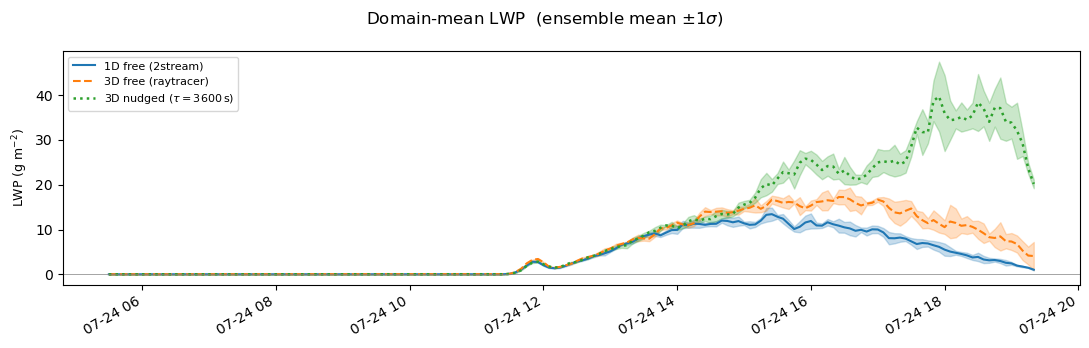

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.5))

ax.plot(t_num_lwp, lwp_1d,    label=LABEL["1D free"],   **STYLE["1D free"])
ax.fill_between(t_num_lwp, lwp_1d - lwp_1d_std, lwp_1d + lwp_1d_std, color="C0", alpha=0.25)

ax.plot(t_num_lwp, lwp_rt,    label=LABEL["3D free"],   **STYLE["3D free"])
ax.fill_between(t_num_lwp, lwp_rt - lwp_rt_std, lwp_rt + lwp_rt_std, color="C1", alpha=0.25)

ax.plot(t_num_lwp, lwp_nudge, label=LABEL["3D nudged"], **STYLE["3D nudged"])
ax.fill_between(t_num_lwp, lwp_nudge - lwp_nudge_std, lwp_nudge + lwp_nudge_std, color="C2", alpha=0.25)

ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel(r"LWP (g m$^{-2}$)", fontsize=9)
ax.legend(fontsize=8)
ax.xaxis_date()
ax.figure.autofmt_xdate()
fig.suptitle(r"Domain-mean LWP  (ensemble mean $\pm 1\sigma$)", fontsize=12)
plt.tight_layout()
_savefig("nudge_lwp_timeseries.pdf", bbox_inches="tight")
plt.show()

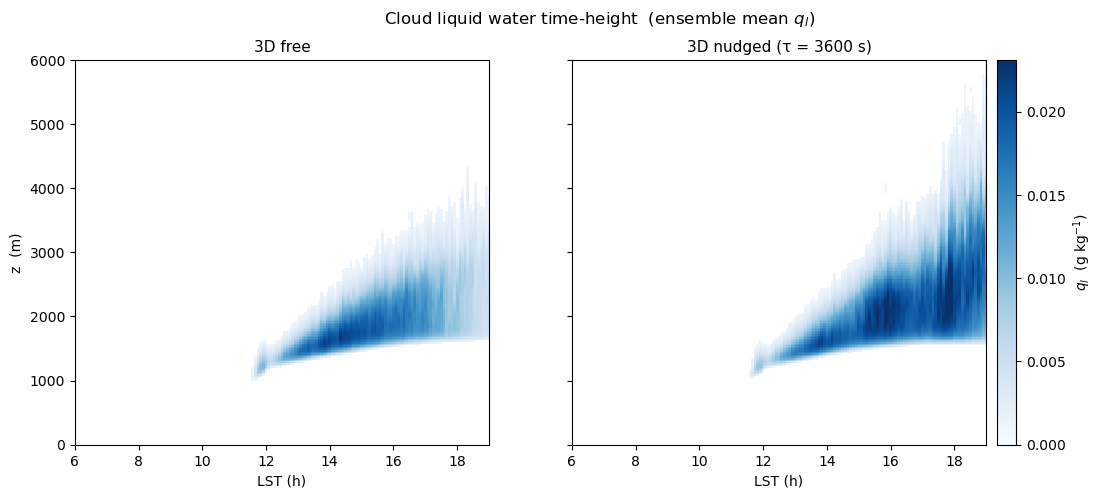

In [9]:
# Time-height cross-section of cloud liquid water  (ensemble mean)
# z on y-axis, time on x-axis, color = q_l (g/kg)
# Two panels: 3D free and 3D nudged
z_max_th = 6000
z_mask_th = z <= z_max_th
z_th = z[z_mask_th]

ql_rt    = thermo['3D free']['ql'][:nt,   z_mask_th]
ql_nudge = thermo['3D nudged']['ql'][:nt, z_mask_th]

vmax = max(np.nanpercentile(ql_rt[ql_rt > 0], 99) if (ql_rt > 0).any() else 0.01,
           np.nanpercentile(ql_nudge[ql_nudge > 0], 99) if (ql_nudge > 0).any() else 0.01)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, ql_arr, title in [
    (axes[0], ql_rt,    f"3D free"),
    (axes[1], ql_nudge, f"3D nudged (\u03c4 = 3600 s)"),
]:
    # mask zeros for cleaner coloring (only show where cloud exists)
    ql_plot = np.where(ql_arr > 0.001, ql_arr, np.nan)
    im = ax.pcolormesh(t_h, z_th, ql_plot.T,
                       cmap='Blues', vmin=0, vmax=vmax, shading='auto')
    ax.set_xlabel('LST (h)')
    ax.set_title(title, fontsize=11)
    ax.set_xlim(6, 19)
    ax.set_ylim(0, z_max_th)

axes[0].set_ylabel('z  (m)')
cbar = fig.colorbar(im, ax=axes, label=r'$q_l$  (g kg$^{-1}$)', pad=0.01)
fig.suptitle(r'Cloud liquid water time-height  (ensemble mean $q_l$)', fontsize=12)

_savefig('nudge_lwp_timez.pdf', bbox_inches='tight')
plt.show()

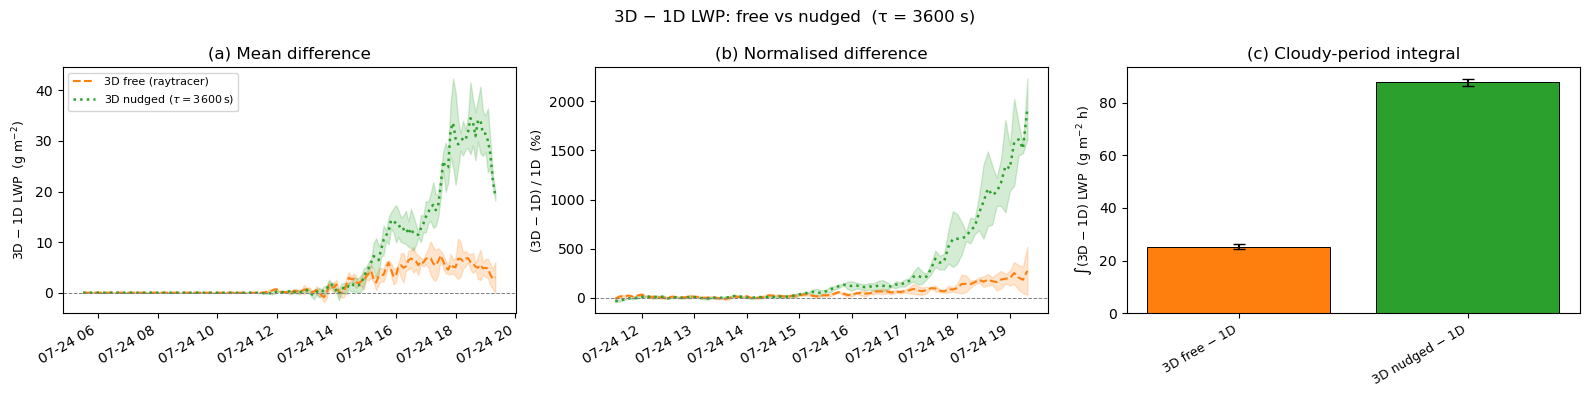

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ax_diff, ax_norm, ax_int = axes

# (a) mean diff vs 1D
ax_diff.plot(t_num_lwp, diff_rt,    label=LABEL["3D free"],   **STYLE["3D free"])
ax_diff.fill_between(t_num_lwp, diff_rt - diff_rt_std, diff_rt + diff_rt_std, color="C1", alpha=0.2)
ax_diff.plot(t_num_lwp, diff_nudge, label=LABEL["3D nudged"], **STYLE["3D nudged"])
ax_diff.fill_between(t_num_lwp, diff_nudge - diff_nudge_std, diff_nudge + diff_nudge_std, color="C2", alpha=0.2)
ax_diff.axhline(0, color="gray", lw=0.7, ls="--")
ax_diff.set_ylabel(r"3D − 1D LWP  (g m$^{-2}$)", fontsize=9)
ax_diff.set_title("(a) Mean difference")
ax_diff.legend(fontsize=8)
ax_diff.xaxis_date()

# (b) normalised diff
ax_norm.plot(t_num_lwp, norm_rt,    **STYLE["3D free"])
ax_norm.fill_between(t_num_lwp, norm_rt - norm_rt_std, norm_rt + norm_rt_std, color="C1", alpha=0.2)
ax_norm.plot(t_num_lwp, norm_nudge, **STYLE["3D nudged"])
ax_norm.fill_between(t_num_lwp, norm_nudge - norm_nudge_std, norm_nudge + norm_nudge_std, color="C2", alpha=0.2)
ax_norm.axhline(0, color="gray", lw=0.7, ls="--")
ax_norm.set_ylabel("(3D − 1D) / 1D  (%)", fontsize=9)
ax_norm.set_title("(b) Normalised difference")
ax_norm.xaxis_date()

# (c) integral bar
for x, (val, err, label, color) in enumerate([
    (int_rt,    int_rt_std,    LABEL["3D free"],   "C1"),
    (int_nudge, int_nudge_std, LABEL["3D nudged"], "C2"),
]):
    ax_int.bar(x, val, color=color, edgecolor="k", lw=0.7)
    ax_int.errorbar(x, val, yerr=err, fmt="none", color="k", capsize=4, lw=1.5)
ax_int.axhline(0, color="gray", lw=0.7)
ax_int.set_xticks([0, 1])
ax_int.set_xticklabels(["3D free − 1D", "3D nudged − 1D"], fontsize=9)
ax_int.set_ylabel(r"$\int$(3D − 1D) LWP  (g m$^{-2}$ h)", fontsize=9)
ax_int.set_title("(c) Cloudy-period integral")

for ax in [ax_diff, ax_norm]:
    ax.figure.autofmt_xdate()

fig.suptitle(r"3D − 1D LWP: free vs nudged  (τ = 3600 s)", fontsize=12)
plt.tight_layout()
_savefig("nudge_lwp_summary.pdf", bbox_inches="tight")
plt.show()

---
## 2. Thermodynamic structure

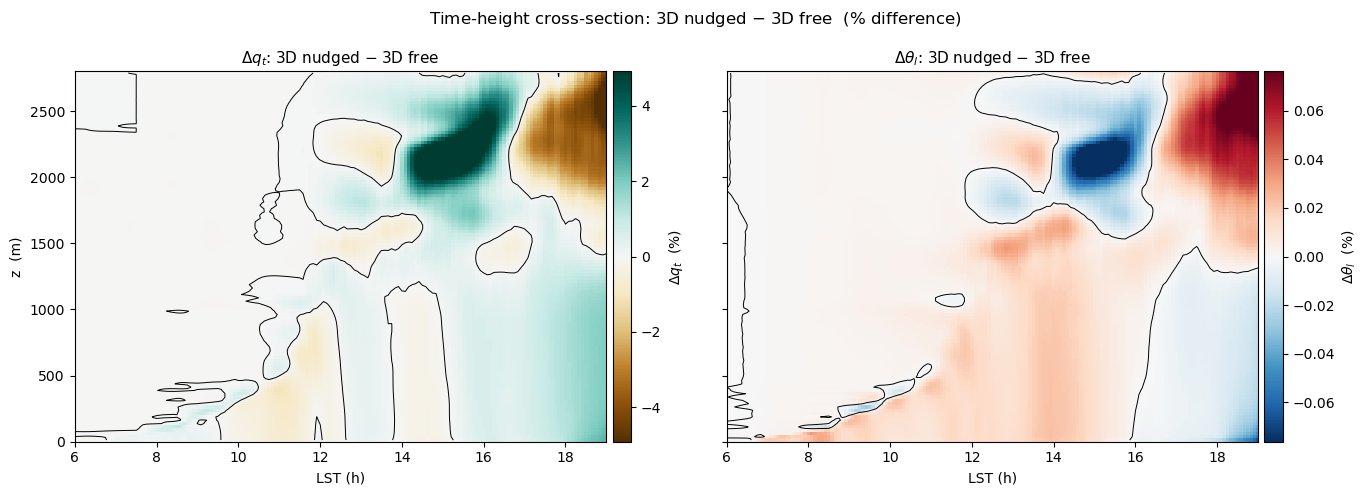

In [11]:
# Time-height cross-section: 3D nudged − 3D free  (percent difference)
z_max  = 2800
z_mask = z <= z_max
z_plot = z[z_mask]

ref_qt  = thermo['3D free']['qt'][:nt,  z_mask]
ref_thl = thermo['3D free']['thl'][:nt, z_mask]
dqt     = thermo['3D nudged']['qt'][:nt,  z_mask] - ref_qt
dthl    = thermo['3D nudged']['thl'][:nt, z_mask] - ref_thl

pct_qt  = np.where(np.abs(ref_qt)  > 0.01, dqt  / np.abs(ref_qt)  * 100, np.nan)
pct_thl = np.where(np.abs(ref_thl) > 0.01, dthl / np.abs(ref_thl) * 100, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

def _hov(ax, t, z, field, cmap, label):
    lim = np.nanpercentile(np.abs(field), 98)
    im  = ax.pcolormesh(t, z, field.T, cmap=cmap, vmin=-lim, vmax=lim, shading='auto')
    ax.contour(t, z, field.T, levels=[0], colors='k', linewidths=0.7)
    plt.colorbar(im, ax=ax, label=label, pad=0.01)
    ax.set_ylim(0, z_max)
    ax.set_xlim(6, 19)

_hov(axes[0], t_h, z_plot, pct_qt,  'BrBG',   r'$\Delta q_t$  (%)')
_hov(axes[1], t_h, z_plot, pct_thl, 'RdBu_r', r'$\Delta \theta_l$  (%)')

axes[0].set_title(r'$\Delta q_t$: 3D nudged $-$ 3D free', fontsize=11)
axes[1].set_title(r'$\Delta \theta_l$: 3D nudged $-$ 3D free', fontsize=11)
axes[0].set_ylabel('z  (m)')
for ax in axes:
    ax.set_xlabel('LST (h)')

fig.suptitle('Time-height cross-section: 3D nudged $-$ 3D free  (% difference)', fontsize=12)
plt.tight_layout()
_savefig("nudge_thermo_timez.pdf", bbox_inches="tight")
plt.show()

### Window-mean thermodynamic profiles

Window-mean = time-average over LST 12:30–17:00 (same as entrainment analysis window).  
If the nudge worked, nudge 3D should track 1D free closely in θ_l and q_t.

/tmp/ipykernel_1974251/1204167287.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


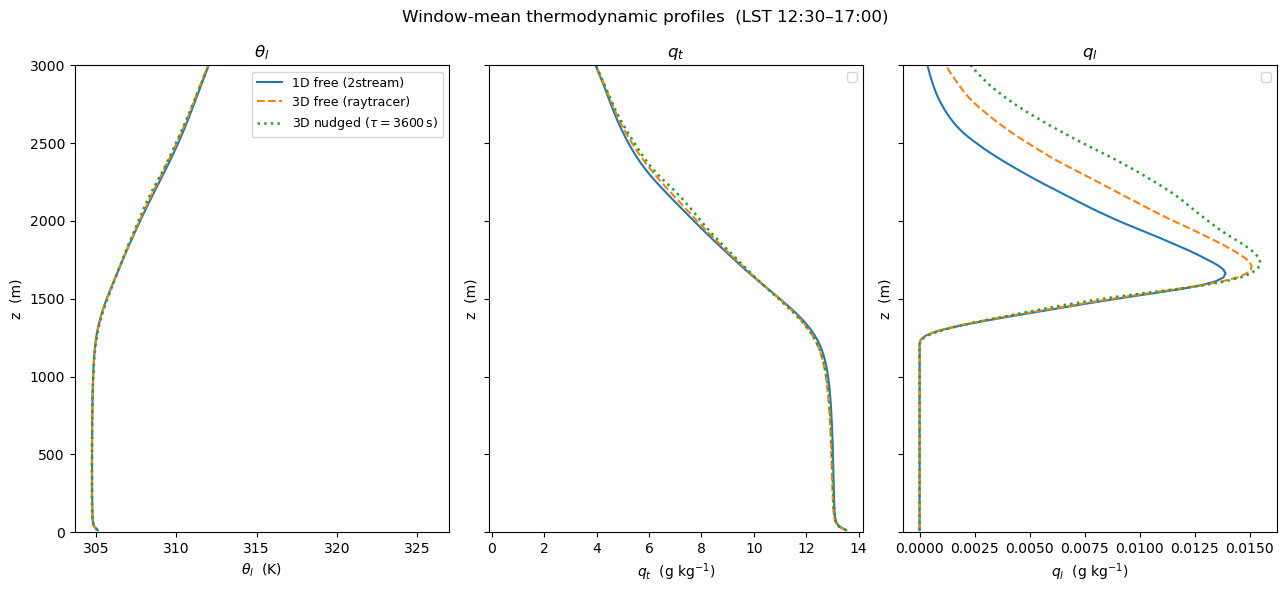

In [12]:
import pandas as _pd

_T0 = _pd.Timestamp("2005-07-24 12:30")
_T1 = _pd.Timestamp("2005-07-24 17:00")


def window_mean_profile(stats_dict, key, t0=_T0, t1=_T1):
    """Time-average of a (nt, nz) profile array within the LST analysis window."""
    t = _pd.DatetimeIndex(stats_dict["t_local"])
    mask = (t >= t0) & (t <= t1)
    return stats_dict[key][mask].mean(axis=0)


# Map to unified stats dicts (already loaded above)
_bls = {
    "1D free":   s2s_mean,
    "3D free":   srt_mean,
    "3D nudged": snudge_mean,
}

# Absolute mean profiles: θ_l, q_t, q_l
fig, axes = plt.subplots(1, 3, figsize=(13, 6), sharey=True)

for run_key, sm in _bls.items():
    st = STYLE[run_key]
    axes[0].plot(window_mean_profile(sm, "thl"),       z, label=LABEL[run_key], **st)
    axes[1].plot(window_mean_profile(sm, "qt") * 1e3,  z, **st)
    axes[2].plot(window_mean_profile(sm, "ql") * 1e3,  z, **st)

axes[0].set_xlabel(r"$\theta_l$  (K)");       axes[0].set_title(r"$\theta_l$")
axes[1].set_xlabel(r"$q_t$  (g kg$^{-1}$)");  axes[1].set_title(r"$q_t$")
axes[2].set_xlabel(r"$q_l$  (g kg$^{-1}$)");  axes[2].set_title(r"$q_l$")
for ax in axes:
    ax.set_ylabel("z  (m)")
    ax.set_ylim(0, 3000)
    ax.legend(fontsize=9)


fig.suptitle("Window-mean thermodynamic profiles  (LST 12:30–17:00)", fontsize=12)
plt.tight_layout()
_savefig("nudge_profiles_mean.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_1974251/3028252076.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


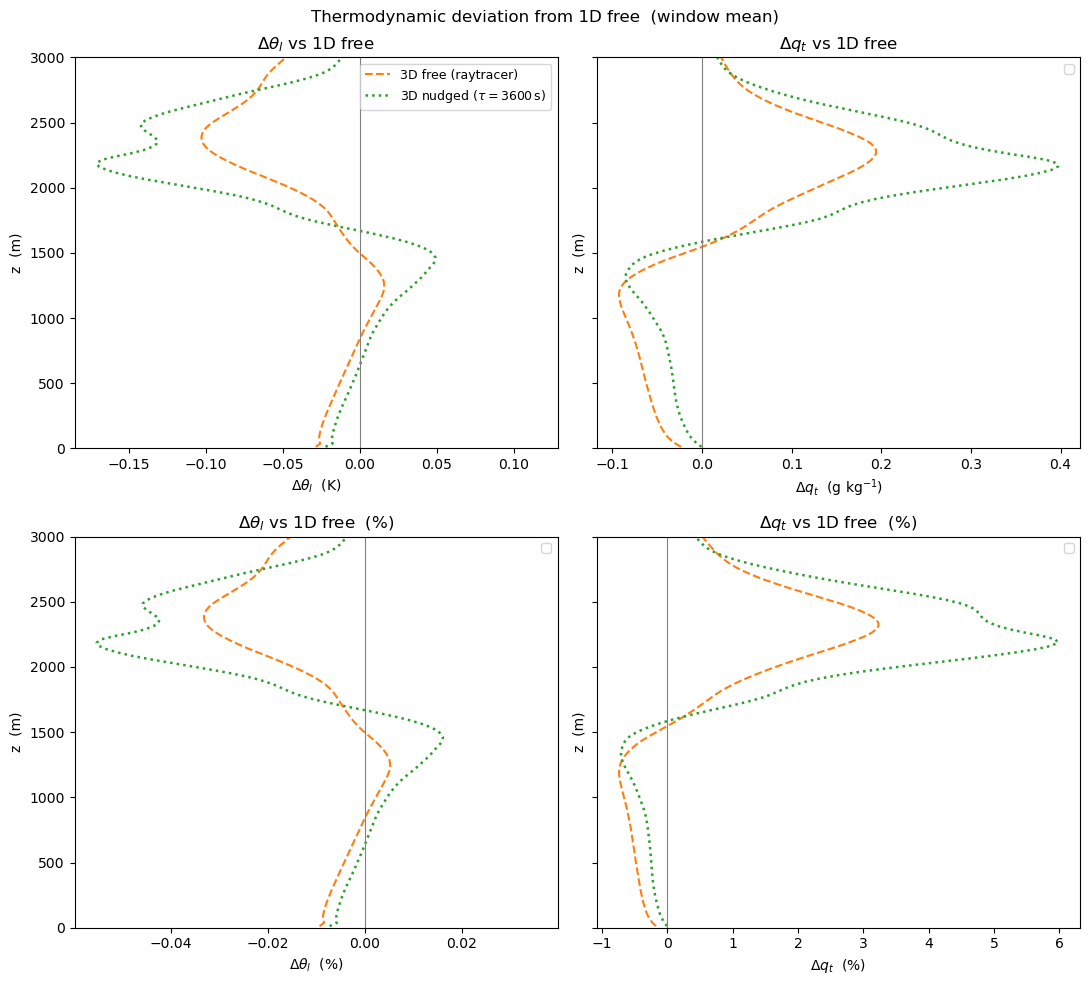

In [13]:
# Thermodynamic deviation from 1D free (window mean)
ref_thl = window_mean_profile(s2s_mean, "thl")
ref_qt  = window_mean_profile(s2s_mean, "qt") * 1e3

fig, axes = plt.subplots(2, 2, figsize=(11, 10), sharey=True)

for run_key in ("3D free", "3D nudged"):
    sm  = _bls[run_key]
    st  = STYLE[run_key]
    d_thl = window_mean_profile(sm, "thl")       - ref_thl
    d_qt  = window_mean_profile(sm, "qt") * 1e3  - ref_qt
    p_thl = d_thl / np.abs(ref_thl) * 100
    p_qt  = d_qt  / np.abs(ref_qt)  * 100

    axes[0, 0].plot(d_thl, z, label=LABEL[run_key], **st)
    axes[0, 1].plot(d_qt,  z, **st)
    axes[1, 0].plot(p_thl, z, **st)
    axes[1, 1].plot(p_qt,  z, **st)

row_labels = [(r"$\Delta\theta_l$  (K)", r"$\Delta q_t$  (g kg$^{-1}$)"),
              (r"$\Delta\theta_l$  (%)", r"$\Delta q_t$  (%)")]
for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        ax.axvline(0, color="0.5", lw=0.8, ls="-")
        ax.set_ylabel("z  (m)")
        ax.set_ylim(0, 3000)
        ax.legend(fontsize=9)
        ax.set_xlabel(row_labels[row][col])

axes[0, 0].set_title(r"$\Delta\theta_l$ vs 1D free")
axes[0, 1].set_title(r"$\Delta q_t$ vs 1D free")
axes[1, 0].set_title(r"$\Delta\theta_l$ vs 1D free  (%)")
axes[1, 1].set_title(r"$\Delta q_t$ vs 1D free  (%)")

fig.suptitle("Thermodynamic deviation from 1D free  (window mean)", fontsize=12)
plt.tight_layout()
_savefig("nudge_thermo_deviation.pdf", bbox_inches="tight")
plt.show()

---
## 3. Surface energy balance

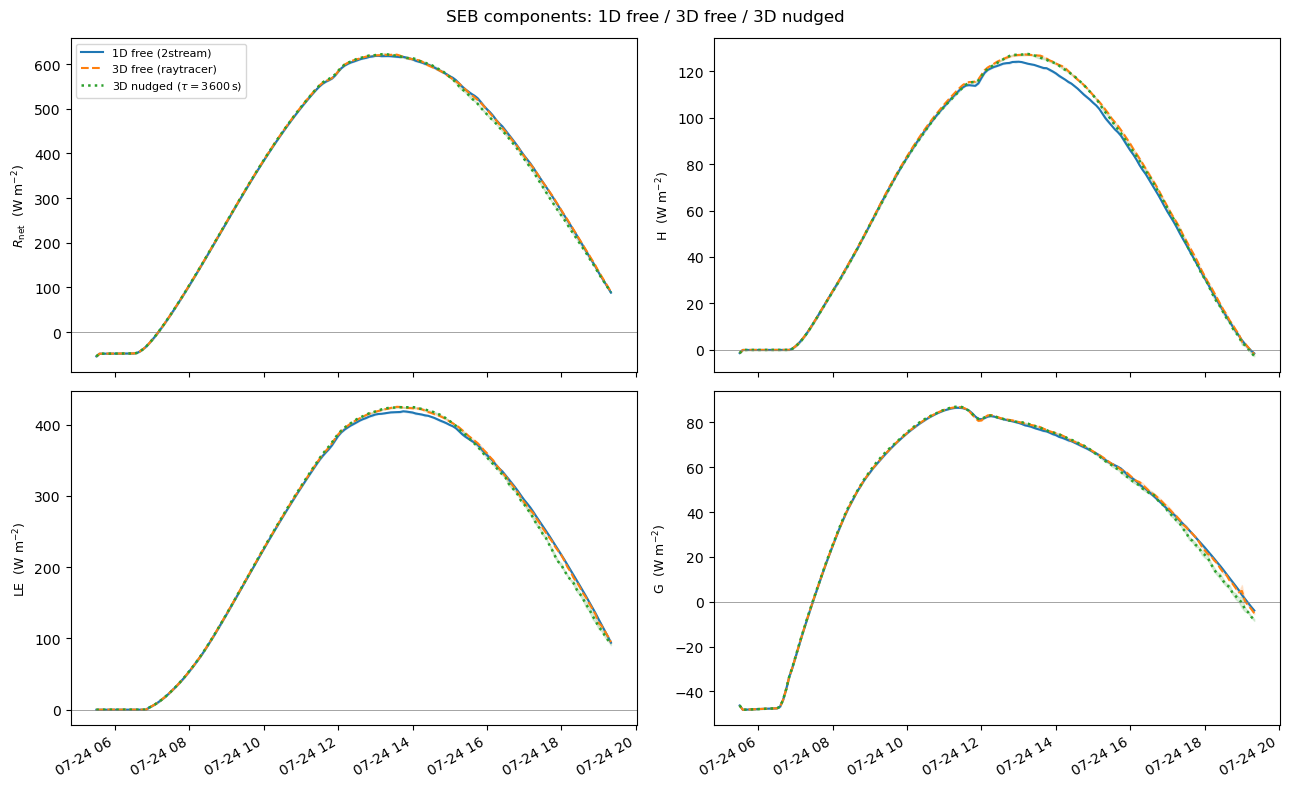

In [14]:
fluxes = ["Rnet", "H", "LE", "G"]
flux_labels = {"Rnet": r"$R_\mathrm{net}$", "H": "H", "LE": "LE", "G": "G"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

for ax, flux in zip(axes.flat, fluxes):
    for run_key, sm, ss in run_data:
        y    = sm[flux][:nt_seb]
        yerr = ss.get(flux)
        if yerr is not None:
            yerr = yerr[:nt_seb]
        ax.plot(t_num, y, label=LABEL[run_key], **STYLE[run_key])
        if yerr is not None:
            ax.fill_between(t_num, y - yerr, y + yerr, color=STYLE[run_key]["color"], alpha=0.15)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_ylabel(f"{flux_labels[flux]}  (W m$^{{-2}}$)", fontsize=9)
    ax.xaxis_date()
    ax.figure.autofmt_xdate()

axes.flat[0].legend(fontsize=8)
fig.suptitle("SEB components: 1D free / 3D free / 3D nudged", fontsize=12)
plt.tight_layout()
_savefig("nudge_seb_components.pdf", bbox_inches="tight")
plt.show()

1D free (2stream)                             peak |resid| =   6.4  daytime mean |resid| =   0.2 W m⁻²
3D free (raytracer)                           peak |resid| =  11.4  daytime mean |resid| =   3.7 W m⁻²
3D nudged ($\tau = 3600\,\mathrm{s}$)         peak |resid| =  12.8  daytime mean |resid| =   4.7 W m⁻²


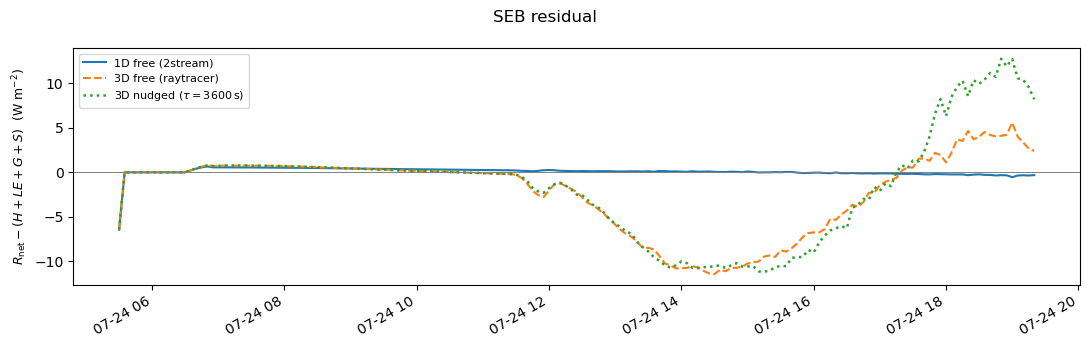

In [15]:
# SEB residual  Rnet − (H + LE + G + S)
# Known: raytracer runs have a larger residual than 2stream.
fig, ax = plt.subplots(figsize=(11, 3.5))

for run_key, sm, ss in run_data:
    resid   = seb_residual({k: sm[k][:nt_seb] for k in sm})
    daytime = sm["Rnet"][:nt_seb] > 50
    ax.plot(t_num, resid, label=LABEL[run_key], **STYLE[run_key])
    print(f"{LABEL[run_key]:44s}  "
          f"peak |resid| = {np.abs(resid).max():5.1f}  "
          f"daytime mean |resid| = {np.abs(resid[daytime]).mean():5.1f} W m⁻²")

ax.axhline(0, color="gray", lw=0.7)
ax.set_ylabel(r"$R_\mathrm{net} - (H+LE+G+S)$  (W m$^{-2}$)", fontsize=9)
ax.legend(fontsize=8)
ax.xaxis_date()
ax.figure.autofmt_xdate()
fig.suptitle("SEB residual", fontsize=12)
plt.tight_layout()
_savefig("nudge_seb_residual.pdf", bbox_inches="tight")
plt.show()

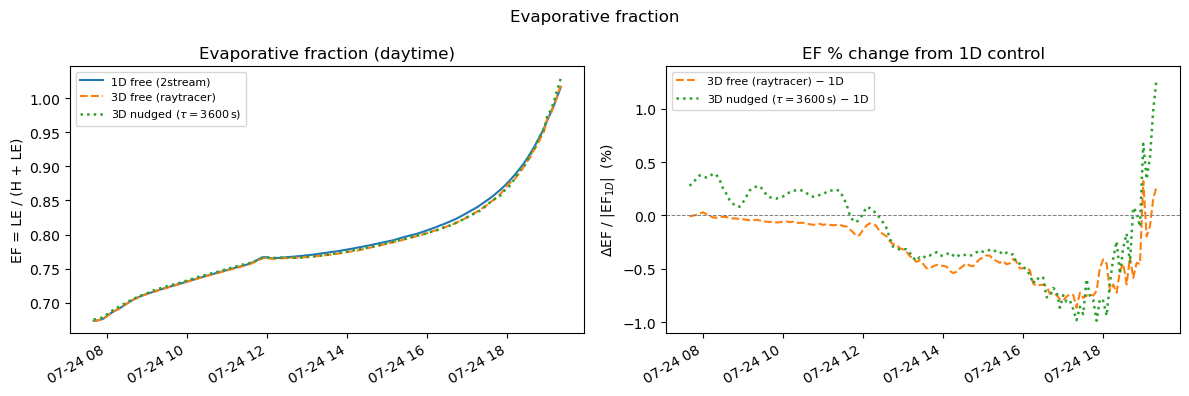

In [16]:
# Evaporative fraction  EF = LE / (H + LE)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

daytime   = s2s_mean["Rnet"][:nt_seb] > 50
t_day     = t_num[daytime]
ef_1d_day = evaporative_fraction({k: s2s_mean[k][:nt_seb] for k in s2s_mean})[daytime]

for run_key, sm, ss in run_data:
    sm_t = {k: sm[k][:nt_seb] for k in sm}
    ef   = evaporative_fraction(sm_t)[daytime]
    axes[0].plot(t_day, ef, label=LABEL[run_key], **STYLE[run_key])

for run_key in ["3D free", "3D nudged"]:
    sm   = next(sm for rk, sm, ss in run_data if rk == run_key)
    sm_t = {k: sm[k][:nt_seb] for k in sm}
    ef   = evaporative_fraction(sm_t)[daytime]
    ef_pct = (ef - ef_1d_day) / np.abs(ef_1d_day) * 100
    axes[1].plot(t_day, ef_pct, label=f"{LABEL[run_key]} − 1D", **STYLE[run_key])

axes[0].set_ylabel("EF = LE / (H + LE)")
axes[0].set_title("Evaporative fraction (daytime)")
axes[0].legend(fontsize=8)

axes[1].axhline(0, color="gray", lw=0.7, ls="--")
axes[1].set_ylabel(r"$\Delta$EF / $|$EF$_{1D}|$  (%)")
axes[1].set_title("EF % change from 1D control")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.xaxis_date()
    ax.figure.autofmt_xdate()

fig.suptitle("Evaporative fraction", fontsize=12)
plt.tight_layout()
_savefig("nudge_seb_ef.pdf", bbox_inches="tight")
plt.show()

### SEB conditioned on cloud mask

In [17]:
CACHE_DIR = Path(os.environ.get("SCRATCH", "/pscratch/sd/m/mpowell")) / "CASS_LES/analysis/seb_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def _compute_cond(result):
    mean_dict, std_dict = result
    for d in (mean_dict, std_dict):
        for kind in d:
            d[kind] = {var: da.compute() for var, da in d[kind].items()}
    return mean_dict, std_dict


def _load_or_compute_cond(rep_dirs, cache_name, variables, force=False):
    cache_file = CACHE_DIR / f"{cache_name}.pkl"
    if not force and cache_file.exists():
        print(f"  [cache hit] {cache_file.name}")
        with open(cache_file, "rb") as fh:
            return pickle.load(fh)
    print(f"  [computing] {cache_name} …")
    result = _compute_cond(conditioned_means_ensemble(rep_dirs, variables=variables))
    with open(cache_file, "wb") as fh:
        pickle.dump(result, fh)
    print(f"  [cached]    {cache_file.name}")
    return result


_VARS_2S = ["thl_fluxbot", "qt_fluxbot", "sw_flux_dn"]
_VARS_RT = ["thl_fluxbot", "qt_fluxbot", "sw_flux_sfc_rt", "sw_flux_dn"]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cond_ctrl_2s_mean, cond_ctrl_2s_std = _load_or_compute_cond(
        dirs_2s,    "experiments_no_aerosols_zero_wind__2stream",             _VARS_2S)
    cond_ctrl_rt_mean, cond_ctrl_rt_std = _load_or_compute_cond(
        dirs_rt,    "experiments_no_aerosols_zero_wind__raytracer",           _VARS_RT)
    cond_nudge_mean,   cond_nudge_std   = _load_or_compute_cond(
        dirs_nudge, "experiments_mean_state_nudge_nudge_3600s__raytracer",    _VARS_RT)

print("All conditioned means ready.")

  [cache hit] experiments_no_aerosols_zero_wind__2stream.pkl
  [cache hit] experiments_no_aerosols_zero_wind__raytracer.pkl
  [cache hit] experiments_mean_state_nudge_nudge_3600s__raytracer.pkl
All conditioned means ready.


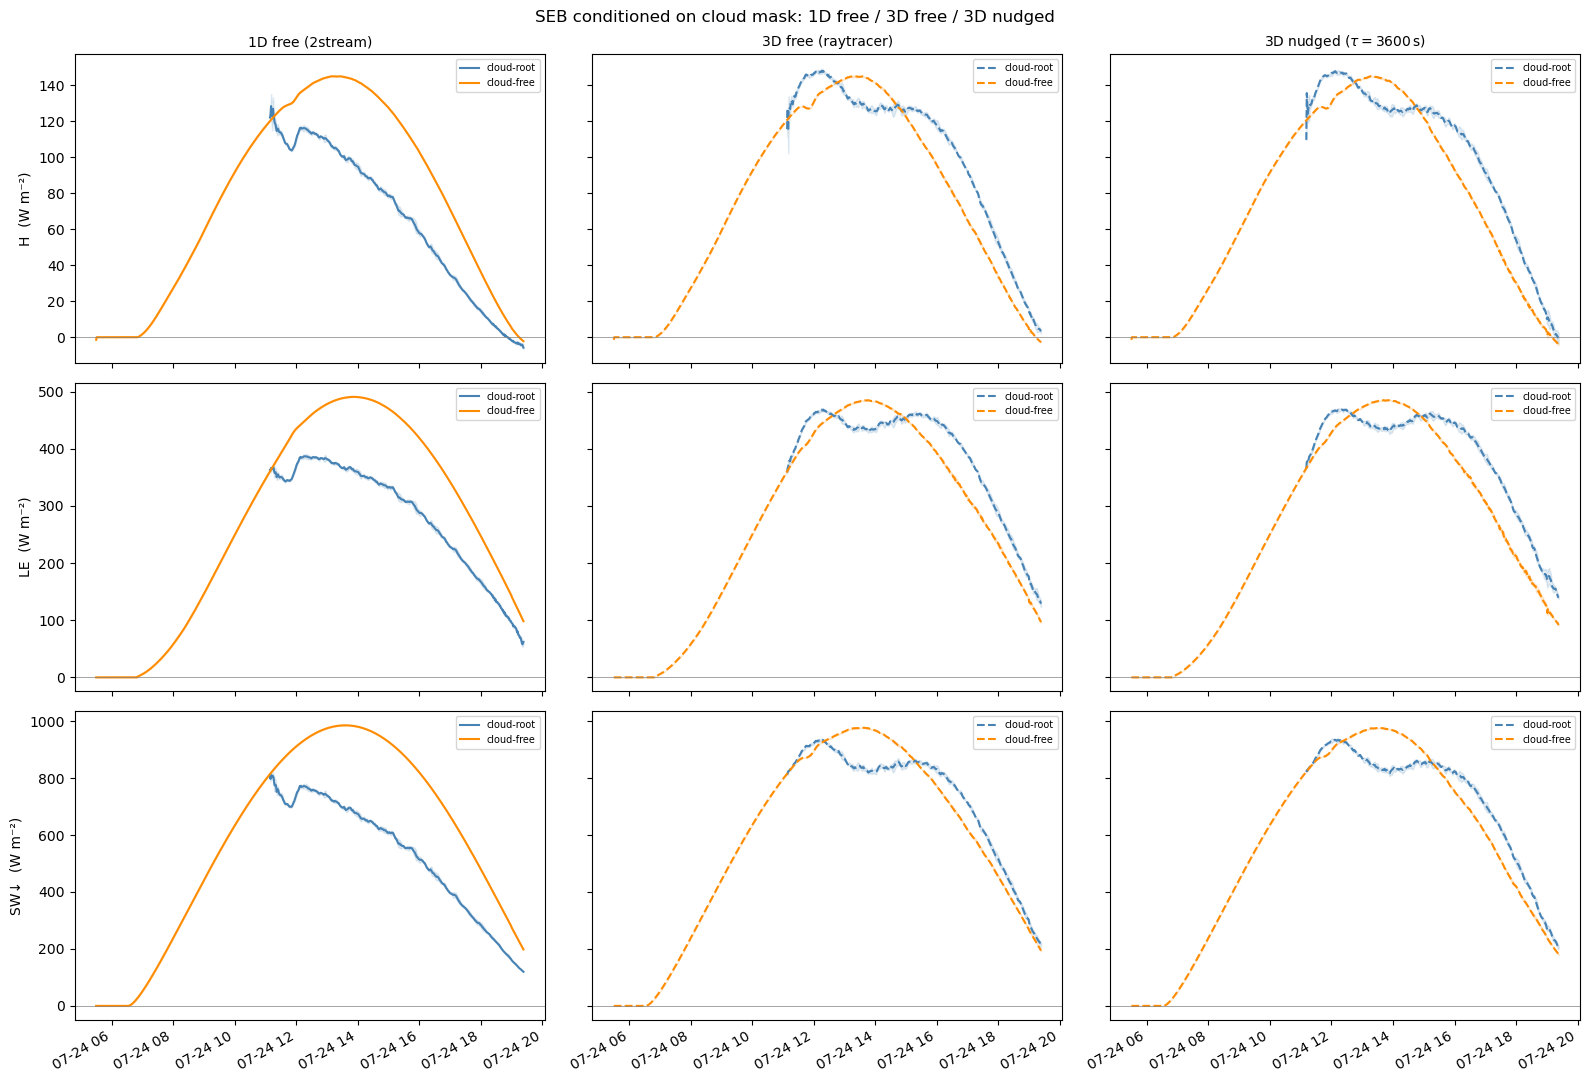

In [18]:
H_scale  = rho * cp
LE_scale = rho * Lv

_runs_cond = [
    ("1D free",   cond_ctrl_2s_mean, cond_ctrl_2s_std, "2stream",   "sw_flux_dn"),
    ("3D free",   cond_ctrl_rt_mean, cond_ctrl_rt_std, "raytracer", "sw_flux_sfc_rt"),
    ("3D nudged", cond_nudge_mean,   cond_nudge_std,   "raytracer", "sw_flux_sfc_rt"),
]
_row_info = [
    ("thl_fluxbot", H_scale,  "H  (W m⁻²)"),
    ("qt_fluxbot",  LE_scale, "LE  (W m⁻²)"),
    (None,          1.0,      "SW↓  (W m⁻²)"),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True, sharey="row")

for col, (run_key, cm, cs, rt_type, sw_key_col) in enumerate(_runs_cond):
    t_local_cond = cm["shaded"]["thl_fluxbot"].time.values
    for row, (var_key, scale, ylabel) in enumerate(_row_info):
        ax   = axes[row, col]
        vkey = sw_key_col if var_key is None else var_key
        plot_flux_conditioned(
            ax, t_local_cond,
            cm["shaded"][vkey],  cm["unshaded"][vkey],
            cs["shaded"].get(vkey), cs["unshaded"].get(vkey),
            rt_type=rt_type, ylabel=ylabel if col == 0 else "", scale=scale,
        )
        if row == 0:
            ax.set_title(LABEL[run_key], fontsize=10)
        if col > 0:
            ax.set_ylabel("")
        ax.legend(fontsize=7)

fig.suptitle("SEB conditioned on cloud mask: 1D free / 3D free / 3D nudged", fontsize=12)
plt.tight_layout()
_savefig("nudge_seb_conditioned_absolute.pdf", bbox_inches="tight")
plt.show()

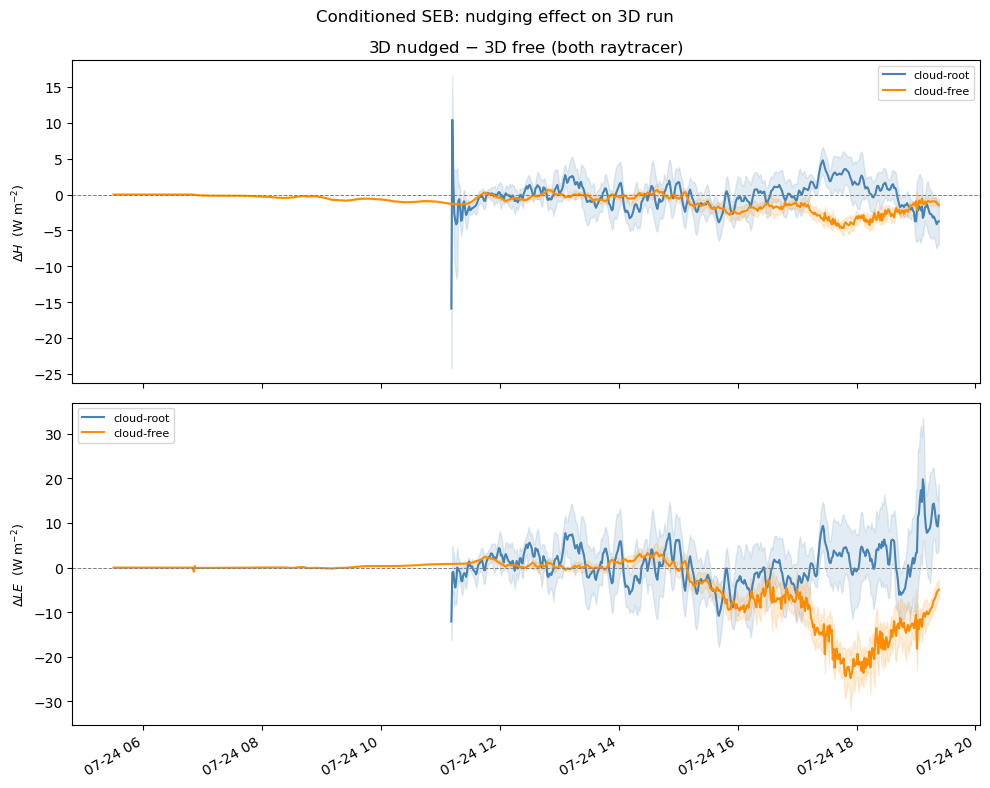

In [19]:
# Anomaly: 3D nudged − 3D free (both raytracer)
_nudge_anom_rows = [
    ("thl_fluxbot",  H_scale,  r"$\Delta H$  (W m$^{-2}$)"),
    ("qt_fluxbot",   LE_scale, r"$\Delta LE$  (W m$^{-2}$)"),
]

_nt_rt = min(
    cond_ctrl_rt_mean["shaded"]["thl_fluxbot"].sizes["time"],
    cond_nudge_mean["shaded"]["thl_fluxbot"].sizes["time"],
)
_t_cond    = cond_ctrl_rt_mean["shaded"]["thl_fluxbot"].time.values[:_nt_rt]
_t_num_cond = _to_plottime(_t_cond)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for ax, (var_key, scale, ylabel) in zip(axes, _nudge_anom_rows):
    for kind, color, kind_label in [("shaded", "steelblue", "cloud-root"), ("unshaded", "darkorange", "cloud-free")]:
        y_free  = np.asarray(cond_ctrl_rt_mean[kind][var_key].isel(time=slice(None, _nt_rt))) * scale
        y_nudge = np.asarray(cond_nudge_mean[kind][var_key].isel(time=slice(None, _nt_rt)))   * scale
        diff    = y_nudge - y_free
        err_f   = np.asarray(cond_ctrl_rt_std[kind][var_key].isel(time=slice(None, _nt_rt))) * scale
        err_n   = np.asarray(cond_nudge_std[kind][var_key].isel(time=slice(None, _nt_rt)))   * scale
        err     = np.sqrt(err_f**2 + err_n**2)
        ax.plot(_t_num_cond, diff, color=color, label=kind_label)
        ax.fill_between(_t_num_cond, diff - err, diff + err, color=color, alpha=0.15)
    ax.axhline(0, color="gray", lw=0.7, ls="--")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.xaxis_date()
    ax.figure.autofmt_xdate()
    ax.legend(fontsize=8)

axes[0].set_title("3D nudged $-$ 3D free (both raytracer)")
fig.suptitle("Conditioned SEB: nudging effect on 3D run", fontsize=12)
plt.tight_layout()
_savefig("nudge_seb_conditioned_anomaly.pdf", bbox_inches="tight")
plt.show()

---
## 4. Entrainment

Method: θ_v flux-jump,  `wᵉ = −⟨w′θ_v′⟩_top / Δθ_v`  (Lilly 1968).  
BL-top = height of min(⟨w′θ_v′⟩) in 500–3500 m window.  
All three runs: no aerosols, zero winds (`no_aerosols_zero_wind` + `mean_state_nudge`).

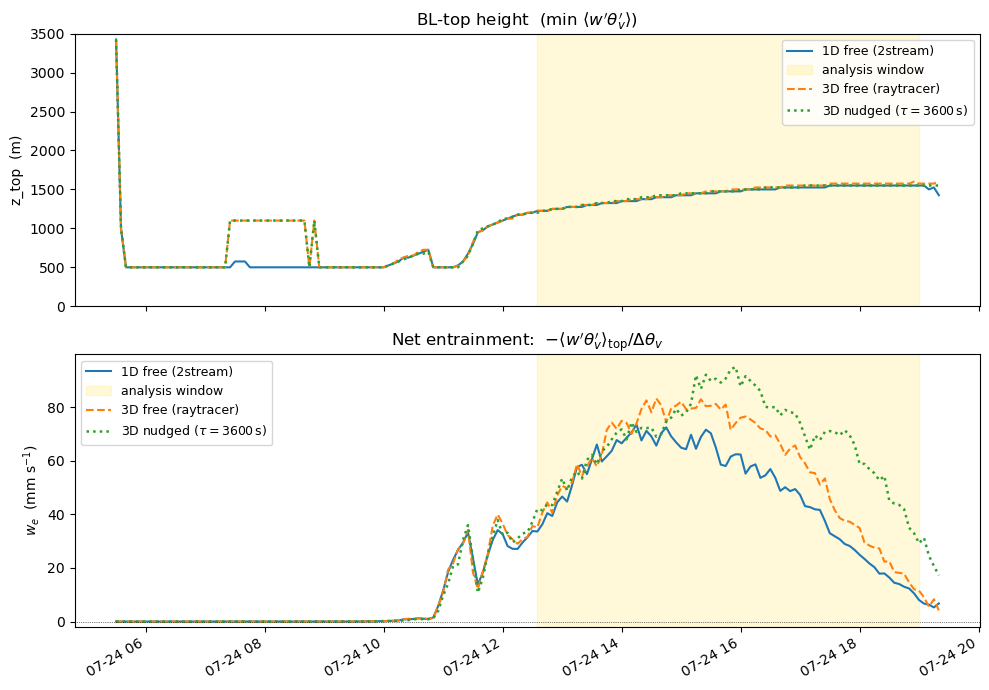

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for ax, key, ylabel, title in [
    (axes[0], "z_top", "z_top  (m)",    "BL-top height  (min $\\langle w'\\theta_v'\\rangle$)"),
    (axes[1], "we",    r"$w_e$  (mm s$^{-1}$)", r"Net entrainment:  $-\langle w'\theta_v'\rangle_\mathrm{top}/\Delta\theta_v$"),
]:
    first = True
    for label, r in results_ent.items():
        t_num_e = _to_plottime(r["t_local"])
        msk     = lst_mask(r["t_local"])
        ax.plot(t_num_e, r[key], label=LABELS_ENT[label], **STYLE_ENT[label])
        if first:
            axvspan_window(ax, r["t_local"], msk, color="gold", alpha=0.15, label="analysis window")
            first = False
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.xaxis_date()

axes[0].set_ylim(0, 3500)
axes[1].axhline(0, color="k", lw=0.5, ls=":")
axes[1].set_ylim(-2, None)

fig.autofmt_xdate()
fig.tight_layout()
_savefig("nudge_entrainment_timeseries.pdf", bbox_inches="tight")
plt.show()

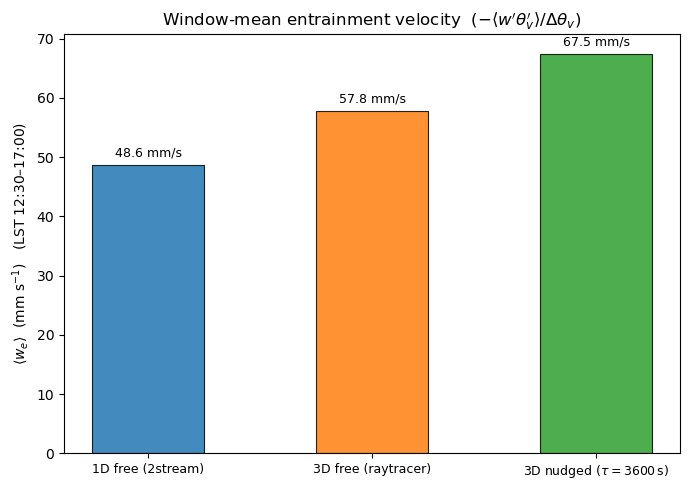

In [21]:
run_labels = list(results_ent.keys())
x = np.arange(len(run_labels))

means = []
for label in run_labels:
    r   = results_ent[label]
    msk = lst_mask(r["t_local"])[:len(r["we"])]
    means.append(np.nanmean(r["we"][msk]))

colors = [STYLE_ENT[l]["color"] for l in run_labels]
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(x, means, 0.5, color=colors, edgecolor="k", lw=0.8, alpha=0.85)
ax.bar_label(bars, fmt="%.1f mm/s", fontsize=9, padding=4)
ax.set_xticks(x)
ax.set_xticklabels([LABELS_ENT[l] for l in run_labels], fontsize=9)
ax.set_ylabel(r"$\langle w_e \rangle$  (mm s$^{-1}$)   (LST 12:30–17:00)")
ax.set_title(r"Window-mean entrainment velocity  $(-\langle w'\theta_v'\rangle/\Delta\theta_v)$")
ax.axhline(0, color="k", lw=0.5)
fig.tight_layout()
_savefig("nudge_entrainment_bar.pdf", bbox_inches="tight")
plt.show()

---
## 5. Cloud-root turbulent structure

Vertical flux profiles (H, LE) conditioned on cloud-root vs cloud-free columns.  
Profiles are computed from 3D netCDF files on first run and cached to `COMPOSITE_ROOT`.  
3D output files (`thl.nc`, `qt.nc`, etc.) must exist in each rep directory.

In [22]:
# Cloud-root configuration
CASES_CR = [
    dict(key='1D',       label='1D (2stream)',          color='C0', ls='-',
         comp_expt='no_aerosols_zero_wind', comp_rt='2stream',
         run_root=str(SCRATCH / 'experiments/no_aerosols_zero_wind/2stream')),
    dict(key='3D',       label='3D free (raytracer)',   color='C1', ls='-',
         comp_expt='no_aerosols_zero_wind', comp_rt='raytracer',
         run_root=str(SCRATCH / 'experiments/no_aerosols_zero_wind/raytracer')),
    dict(key='3D_nudge', label='3D nudged (raytracer)', color='C2', ls='--',
         comp_expt='mean_state_nudge/nudge_3600s', comp_rt='raytracer',
         run_root=str(SCRATCH / 'experiments/mean_state_nudge/nudge_3600s/raytracer')),
]

LST_MIN_CR, LST_MAX_CR = 10.5, 17.5

_RHO_CP = 1.2 * 1005.0         # rho * cp  [K m/s -> W/m^2]
_RHO_LV = 1.2 * 2.5e6 * 1e-3   # rho * Lv * 1e-3  [g/kg m/s -> W/m^2]


def _compute_and_cache_profiles(case, n_reps=N_REPS, lst_min=LST_MIN_CR, lst_max=LST_MAX_CR):
    """Compute cloud-root flux profiles, cache results, return abs profiles + cloud fractions.

    On first run loads 3D netCDF fields (thl.nc, qt.nc, ql.nc, w.nc) per rep and
    caches raw profiles to raw_flux_profile_cache.nc in COMPOSITE_ROOT.
    Subsequent runs read from the cache.
    """
    run_root = Path(case['run_root'])
    H_dom_reps,  H_root_reps,  H_free_reps  = [], [], []
    LE_dom_reps, LE_root_reps, LE_free_reps = [], [], []
    cloud_frac_reps = []
    zeta = None

    for i in range(1, n_reps + 1):
        rep_dir = run_root / f'rep_{i:02d}'
        cache = (COMPOSITE_ROOT / case['comp_expt'] / case['comp_rt']
                 / f'rep_{i:02d}' / 'raw_flux_profile_cache.nc')

        # Invalidate stale cache
        if cache.exists():
            with xr.open_dataset(str(cache)) as _chk:
                if 'f_free_thl' not in _chk or 't_hours' not in _chk:
                    print(f"  {case['key']} rep_{i:02d}: cache outdated, recomputing")
                    cache.unlink()

        if not cache.exists():
            if not (rep_dir / 'thl.nc').exists():
                print(f"  SKIP {case['key']} rep_{i:02d}: thl.nc not found")
                continue
            print(f"  {case['key']} rep_{i:02d}: computing from 3D fields ...", flush=True)
            s     = load_stats(rep_dir)
            ds_3d = load_3d_nc(rep_dir, variables=['thl', 'qt', 'ql', 'w'])
            ds_xy = load_xy_files(rep_dir, variables=['qlqi_path'])
            res   = compute_normalized_cloud_root_profiles(ds_3d, ds_xy, s)
            ds_3d.close()
            if res['f_cloud_thl'].shape[0] == 0:
                print(f"    WARNING: no valid timesteps, skipping")
                continue
            cache.parent.mkdir(parents=True, exist_ok=True)
            xr.Dataset({
                'f_cloud_thl':  xr.DataArray(res['f_cloud_thl'],  dims=['time', 'zeta']),
                'f_cloud_qv':   xr.DataArray(res['f_cloud_qv'],   dims=['time', 'zeta']),
                'f_free_thl':   xr.DataArray(res['f_free_thl'],   dims=['time', 'zeta']),
                'f_free_qv':    xr.DataArray(res['f_free_qv'],    dims=['time', 'zeta']),
                'f_domain_thl': xr.DataArray(res['f_domain_thl'], dims=['time', 'zeta']),
                'f_domain_qv':  xr.DataArray(res['f_domain_qv'],  dims=['time', 'zeta']),
                'z_sl':         xr.DataArray(res['z_sl'],          dims=['time']),
                'cloud_frac':   xr.DataArray(res['cloud_frac'],    dims=['time']),
                't_hours':      xr.DataArray(res['t_hours'],       dims=['time']),
            }, coords={'zeta': res['zeta']}).to_netcdf(str(cache))
            print(f"    cached ({res['f_cloud_thl'].shape[0]} timesteps)")
        else:
            print(f"  {case['key']} rep_{i:02d}: cache hit")

        # Load and accumulate from cache
        ds = xr.open_dataset(str(cache))
        zeta   = ds['zeta'].values
        t_hrs  = ds['t_hours'].values
        mask_t = (t_hrs >= lst_min) & (t_hrs <= lst_max)
        if mask_t.sum() == 0:
            ds.close()
            continue
        H_dom_reps.append( np.nanmean(ds['f_domain_thl'].values[mask_t] * _RHO_CP, axis=0))
        H_root_reps.append(np.nanmean(ds['f_cloud_thl'].values[mask_t]  * _RHO_CP, axis=0))
        H_free_reps.append(np.nanmean(ds['f_free_thl'].values[mask_t]   * _RHO_CP, axis=0))
        LE_dom_reps.append( np.nanmean(ds['f_domain_qv'].values[mask_t] * _RHO_LV, axis=0))
        LE_root_reps.append(np.nanmean(ds['f_cloud_qv'].values[mask_t]  * _RHO_LV, axis=0))
        LE_free_reps.append(np.nanmean(ds['f_free_qv'].values[mask_t]   * _RHO_LV, axis=0))
        cloud_frac_reps.append(float(np.nanmean(ds['cloud_frac'].values[mask_t])))
        ds.close()

    n = len(H_dom_reps)

    def _stack(lst):
        return np.stack(lst) if lst else np.empty((0,))

    return (
        dict(zeta=zeta, n_reps=n,
             H_dom=_stack(H_dom_reps),   H_root=_stack(H_root_reps),   H_free=_stack(H_free_reps),
             LE_dom=_stack(LE_dom_reps), LE_root=_stack(LE_root_reps), LE_free=_stack(LE_free_reps)),
        np.array(cloud_frac_reps),
    )


abs_profiles, cloud_fracs = {}, {}
for case in CASES_CR:
    print(f"\n{case['label']}")
    ap, cf = _compute_and_cache_profiles(case)
    abs_profiles[case['key']] = ap
    cloud_fracs[case['key']]  = cf
    if len(cf) > 0:
        sd = cf.std(ddof=1) if len(cf) > 1 else 0.0
        print(f"  -> {ap['n_reps']} reps  alpha = {cf.mean():.3f} +/- {sd:.3f}")



1D (2stream)
  1D rep_01: cache hit
  1D rep_02: cache hit
  1D rep_03: cache hit
  1D rep_04: cache hit
  -> 4 reps  alpha = 0.112 +/- 0.001

3D free (raytracer)
  3D rep_01: cache hit
  3D rep_02: cache hit
  3D rep_03: cache hit
  3D rep_04: cache hit
  -> 4 reps  alpha = 0.115 +/- 0.001

3D nudged (raytracer)
  3D_nudge rep_01: cache hit
  3D_nudge rep_02: cache hit
  3D_nudge rep_03: cache hit
  3D_nudge rep_04: cache hit
  -> 4 reps  alpha = 0.123 +/- 0.003


/tmp/ipykernel_1974251/2646988962.py:82: RuntimeWarning: Mean of empty slice
  H_dom_reps.append( np.nanmean(ds['f_domain_thl'].values[mask_t] * _RHO_CP, axis=0))
/tmp/ipykernel_1974251/2646988962.py:83: RuntimeWarning: Mean of empty slice
  H_root_reps.append(np.nanmean(ds['f_cloud_thl'].values[mask_t]  * _RHO_CP, axis=0))
/tmp/ipykernel_1974251/2646988962.py:84: RuntimeWarning: Mean of empty slice
  H_free_reps.append(np.nanmean(ds['f_free_thl'].values[mask_t]   * _RHO_CP, axis=0))
/tmp/ipykernel_1974251/2646988962.py:85: RuntimeWarning: Mean of empty slice
  LE_dom_reps.append( np.nanmean(ds['f_domain_qv'].values[mask_t] * _RHO_LV, axis=0))
/tmp/ipykernel_1974251/2646988962.py:86: RuntimeWarning: Mean of empty slice
  LE_root_reps.append(np.nanmean(ds['f_cloud_qv'].values[mask_t]  * _RHO_LV, axis=0))
/tmp/ipykernel_1974251/2646988962.py:87: RuntimeWarning: Mean of empty slice
  LE_free_reps.append(np.nanmean(ds['f_free_qv'].values[mask_t]   * _RHO_LV, axis=0))
/tmp/ipykernel_1974251

/tmp/ipykernel_1974251/3363872277.py:23: RuntimeWarning: Mean of empty slice
  mu  = np.nanmean(arr, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


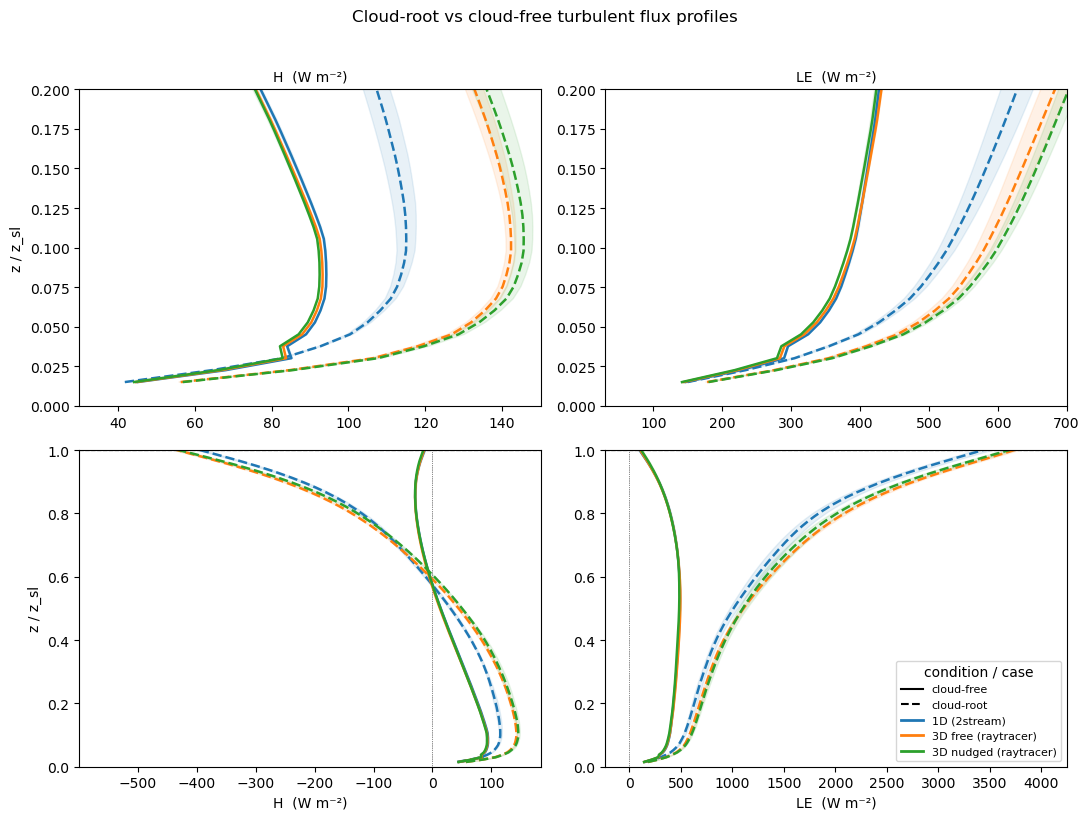

In [23]:
# Absolute H and LE profiles: cloud-root vs cloud-free
# Lines: solid = cloud-free, dashed = cloud-root; colour = case
CONDS = [('H_root', 'LE_root', 'cloud-root', '--'),
         ('H_free', 'LE_free', 'cloud-free',  '-')]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for case in CASES_CR:
    ap = abs_profiles[case['key']]
    if ap['n_reps'] == 0:
        continue
    zeta = ap['zeta']
    for col, var in enumerate(['H', 'LE']):
        for row in range(2):
            ax = axes[row, col]
            ax.axhline(1.0, color='gray', ls='--', lw=0.8)
            ax.axvline(0,   color='gray', ls=':',  lw=0.5)
            ax.set_ylim(0, 0.2 if row == 0 else 1)
            if row == 0:
                ax.set_xlim(30, 150 if var == 'H' else 700)
            for h_key, le_key, lbl, ls in CONDS:
                arr = ap[h_key if var == 'H' else le_key]
                mu  = np.nanmean(arr, axis=0)
                sd  = (np.nanstd(arr, axis=0, ddof=1)
                       if ap['n_reps'] > 1 else np.zeros_like(mu))
                ax.plot(mu, zeta, color=case['color'], ls=ls, lw=1.8)
                ax.fill_betweenx(zeta, mu - sd, mu + sd,
                                 alpha=0.10, color=case['color'])
            if row == 0:
                ax.set_title('H  (W m\u207b\u00b2)' if var == 'H'
                             else 'LE  (W m\u207b\u00b2)', fontsize=10)
            if row == 1:
                ax.set_xlabel('H  (W m\u207b\u00b2)' if var == 'H'
                              else 'LE  (W m\u207b\u00b2)')
            if col == 0:
                ax.set_ylabel('z / z_sl')

legend_style = [Line2D([0], [0], color='k', ls='-',  lw=1.5, label='cloud-free'),
                Line2D([0], [0], color='k', ls='--', lw=1.5, label='cloud-root')]
legend_cases = [Line2D([0], [0], color=c['color'], lw=2, label=c['label'])
                for c in CASES_CR]
axes[1, 1].legend(handles=legend_style + legend_cases, fontsize=8,
                  loc='lower right', title='condition / case')

fig.suptitle('Cloud-root vs cloud-free turbulent flux profiles', y=1.02)
plt.tight_layout()
_savefig('nudge_cloudroot_flux_profiles.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1974251/2172692866.py:18: RuntimeWarning: Mean of empty slice
  base_dom  = np.nanmean(ap_base[dom_key],  axis=0)
/tmp/ipykernel_1974251/2172692866.py:19: RuntimeWarning: Mean of empty slice
  base_root = np.nanmean(ap_base[root_key], axis=0)
/tmp/ipykernel_1974251/2172692866.py:20: RuntimeWarning: Mean of empty slice
  base_free = np.nanmean(ap_base[free_key], axis=0)
/tmp/ipykernel_1974251/2172692866.py:36: RuntimeWarning: Mean of empty slice
  mu_dom  = np.nanmean(ap[dom_key],  axis=0)
/tmp/ipykernel_1974251/2172692866.py:37: RuntimeWarning: Mean of empty slice
  mu_root = np.nanmean(ap[root_key], axis=0)
/tmp/ipykernel_1974251/2172692866.py:38: RuntimeWarning: Mean of empty slice
  mu_free = np.nanmean(ap[free_key], axis=0)


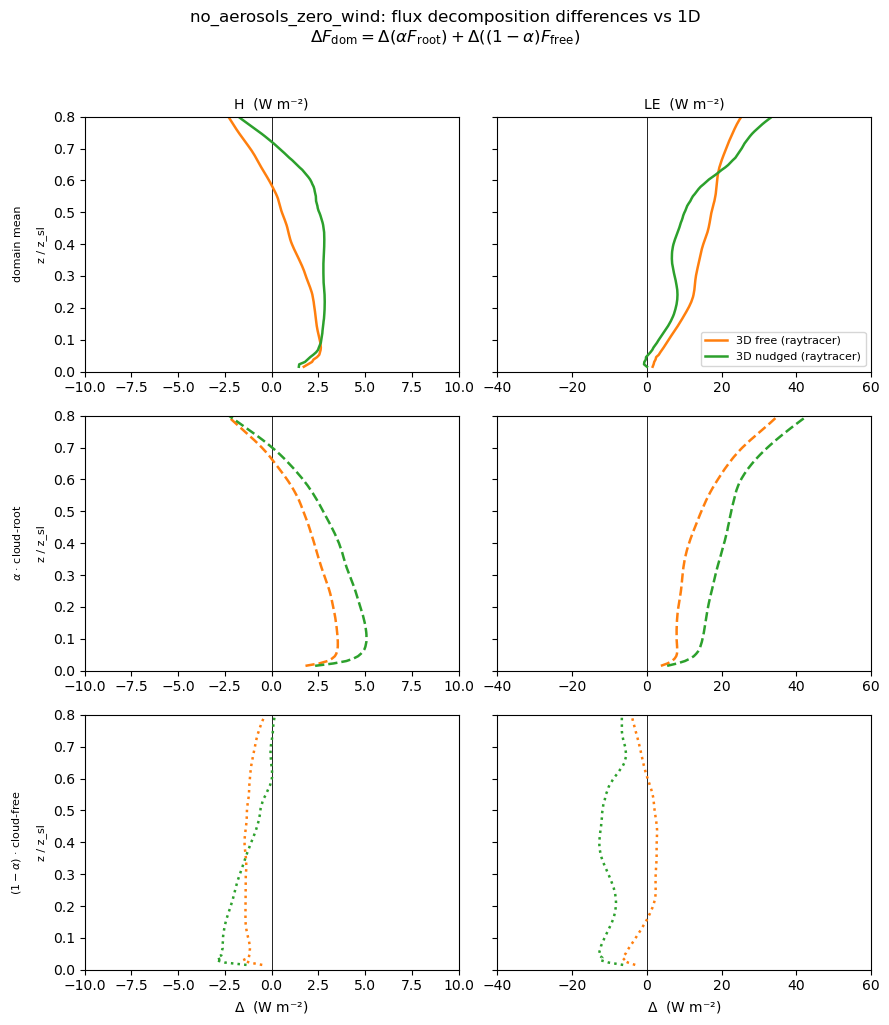

In [24]:
# Flux decomposition differences vs 1D baseline
_baseline_key = '1D'
_diff_cases   = [c for c in CASES_CR if c['key'] != _baseline_key]
ap_base        = abs_profiles[_baseline_key]
alpha_base     = float(cloud_fracs[_baseline_key].mean()) if len(cloud_fracs[_baseline_key]) > 0 else np.nan

_comp_labels = ['domain mean', r'$\alpha$ · cloud-root', r'$(1-\alpha)$ · cloud-free']
_comp_ls     = ['-', '--', ':']

fig, axes = plt.subplots(3, 2, figsize=(9, 10), sharey=True)
_xlims = {'H': (-10, 10), 'LE': (-40, 60)}

for col, var in enumerate(['H', 'LE']):
    dom_key  = f'{var}_dom'
    root_key = f'{var}_root'
    free_key = f'{var}_free'
    zeta = ap_base['zeta']
    base_dom  = np.nanmean(ap_base[dom_key],  axis=0)
    base_root = np.nanmean(ap_base[root_key], axis=0)
    base_free = np.nanmean(ap_base[free_key], axis=0)
    base_cr = alpha_base * base_root
    base_cf = (1 - alpha_base) * base_free

    for row, (comp_label, comp_ls) in enumerate(zip(_comp_labels, _comp_ls)):
        ax = axes[row, col]
        ax.axhline(1.0, color='gray', ls='--', lw=0.8)
        ax.axvline(0,   color='k',    ls='-',  lw=0.6)
        ax.set_ylim(0, 0.8)
        ax.set_xlim(*_xlims[var])
        for case in _diff_cases:
            ap    = abs_profiles[case['key']]
            fracs = cloud_fracs[case['key']]
            if ap['n_reps'] == 0:
                continue
            alpha_mu = float(fracs.mean()) if len(fracs) > 0 else np.nan
            mu_dom  = np.nanmean(ap[dom_key],  axis=0)
            mu_root = np.nanmean(ap[root_key], axis=0)
            mu_free = np.nanmean(ap[free_key], axis=0)
            if row == 0:
                diff = mu_dom - base_dom
            elif row == 1:
                diff = alpha_mu * mu_root - base_cr
            else:
                diff = (1 - alpha_mu) * mu_free - base_cf
            ax.plot(diff, zeta, color=case['color'], lw=1.8, ls=comp_ls, label=case['label'])
        if row == 0:
            ax.set_title('H  (W m⁻²)' if var == 'H' else 'LE  (W m⁻²)', fontsize=10)
        if row == 2:
            ax.set_xlabel(r'$\Delta$  (W m⁻²)')
        if col == 0:
            ax.set_ylabel(comp_label + '\n\nz / z_sl', fontsize=8)

legend_d = [Line2D([0],[0], color=c['color'], lw=1.8, label=c['label']) for c in _diff_cases]
axes[0, 1].legend(handles=legend_d, fontsize=8, loc='lower right')

fig.suptitle(
    'no_aerosols_zero_wind: flux decomposition differences vs 1D\n'
    r'$\Delta F_\mathrm{dom} = \Delta(\alpha F_\mathrm{root}) + \Delta((1-\alpha)F_\mathrm{free})$',
    y=1.02)
plt.tight_layout()
_savefig('nudge_cloudroot_decomposition.pdf', bbox_inches='tight')
plt.show()